In [1]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import uproot
from variables_calculator import variables_calculator

2026-02-22 20:29:14.762885: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 20:29:14.763264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 20:29:14.810218: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-22 20:29:15.109927: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
model = keras.models.load_model("/tf/Higgs-Boson-LHC-Collision-Detector/Trials-ANN/ResNet-SnB-Classificator.keras")

2026-02-22 20:29:18.630729: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-22 20:29:18.859061: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-22 20:29:18.862226: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
# Create the dataframe for validation
sg = pd.read_csv("/tf/Higgs-Boson-LHC-Collision-Detector/Datasets/Signal.csv")
bg = pd.read_csv("/tf/Higgs-Boson-LHC-Collision-Detector/Datasets/Background.csv")

val = pd.concat([sg, bg])
val = val.drop(columns = ["Unnamed: 0"])

# Now we can create the subsets:

X_val = val.drop(columns = ["label"])
y_val = val["label"]

# And we stardardize the data:

scaler = StandardScaler()
X_val = scaler.fit_transform(X_val)

# Check the size
print("Test size:", len(X_val))

Test size: 554161


In [4]:
val.head()

,PRI_jet_leading_pt,PRI_jet_subleading_pt,PRI_jet_leading_eta,PRI_jet_subleading_eta,PRI_jet_leading_phi,PRI_jet_subleading_phi,PRI_jet_num,PRI_jet_all_pt,PRI_met,PRI_met_phi,DER_mass_jet_jet,label,DER_mass_lep
0,97.789630,88.065651,0.878810,-0.736570,2.420791,-0.375482,3,205.81944,29.468515,-1.191945,247.457836,1,92.92551
1,69.906850,64.256523,1.287713,-0.113773,0.435103,2.964018,3,170.76060,4.302101,-1.388696,163.397858,1,85.01884
2,89.023056,83.168976,-0.946320,-0.037001,0.552948,-3.103319,3,213.83180,3.446327,-2.115567,185.076162,1,102.90548
3,137.439440,127.212677,-0.173504,0.348251,-0.170474,-3.009968,3,304.22787,4.129518,2.948901,270.594198,1,82.36900
4,49.592335,46.715462,-1.677774,1.727845,-1.408155,1.710724,2,96.30780,3.077592,2.085408,272.981686,1,92.66223


In [5]:
X_val[0].shape

(12,)

In [6]:
# We check the performance of the validation

loss, accuracy, precision, auc, auc_1 = model.evaluate(X_val, y_val, verbose = 1)

print(f"Test Loss: {loss:}")
print(f"Test Accuracy: {accuracy:}")

17318/17318 [==============================] - 78s 4ms/step - loss: 0.0201 - accuracy: 0.9994 - precision: 0.9995 - auc: 0.9996 - auc_1: 0.9998
Test Loss: 0.020116351544857025
Test Accuracy: 0.9994423985481262


In [7]:
# And we check the predictions

y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

17318/17318 [==============================] - 54s 3ms/step


In [8]:
real_data = pd.concat([sg, bg])
real_data = real_data.drop(columns = ["Unnamed: 0"])
predicted_data = real_data.drop(columns = ["label"])
predicted_data["label"] = y_pred_classes

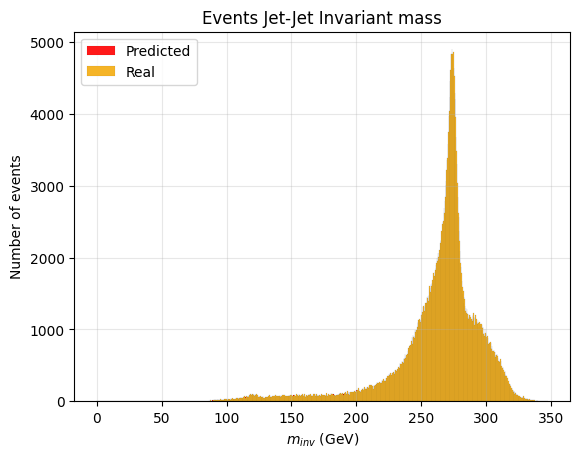

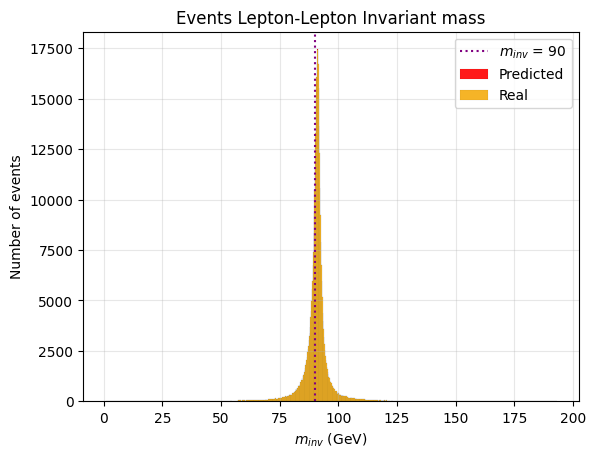

In [9]:
df_predicted_signal = predicted_data[predicted_data["label"] != 0].copy()
df_real_signal = real_data[real_data["label"] != 0].copy()

sns.histplot(df_predicted_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Jet-Jet Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

sns.histplot(df_predicted_signal["DER_mass_lep"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_signal["DER_mass_lep"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.axvline(x = 90, color = "purple", linestyle = ':', label = rf"$m_{{inv}}$ = 90")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Lepton-Lepton Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

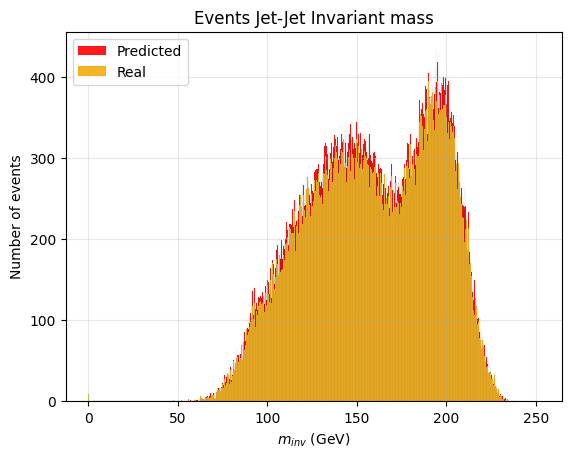

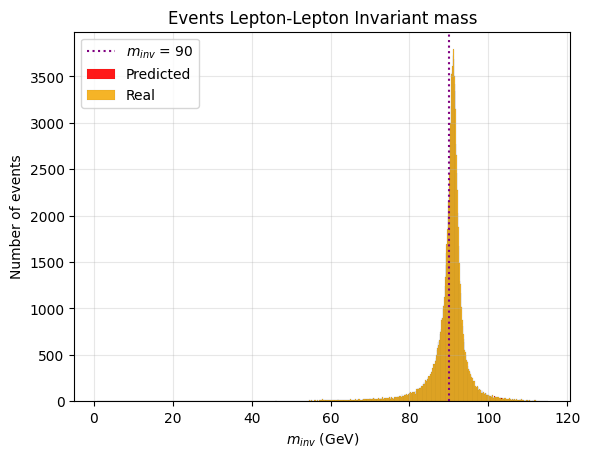

In [10]:
df_predicted_background = predicted_data[predicted_data["label"] == 0].copy()
df_real_background = real_data[real_data["label"] == 0].copy()

sns.histplot(df_predicted_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Jet-Jet Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

sns.histplot(df_predicted_background["DER_mass_lep"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_background["DER_mass_lep"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.axvline(x = 90, color = "purple", linestyle = ':', label = rf"$m_{{inv}}$ = 90")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Lepton-Lepton Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

In [11]:
import uproot
from variables_calculator import variables_calculator

file = "/tf/Higgs-Boson-LHC-Collision-Detector/sigfcc_350.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 0)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

signal = pd.merge(jets_data, lepton_data, on = "event_1")
signal = signal.drop(columns = ["event_1"])

file = "/tf/Higgs-Boson-LHC-Collision-Detector/bgd240zh.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 1)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

noise = pd.merge(jets_data, lepton_data, on = "event_1")
noise = noise.drop(columns = ["event_1"])

val = pd.concat([signal, noise])

val.head()

,PRI_jet_all_pt,PRI_jet_num,PRI_met,PRI_met_phi,PRI_jet_leading_pt,PRI_jet_subleading_pt,PRI_jet_leading_eta,PRI_jet_subleading_eta,PRI_jet_leading_phi,PRI_jet_subleading_phi,DER_mass_jet_jet,label,DER_mass_lep
0,170.760605,3,4.302101,-1.388696,64.256523,36.597229,-0.113773,-1.709504,2.964018,-1.596112,113.084663,0,85.018837
1,304.227875,3,4.129518,2.948901,39.575764,127.212677,-0.525154,0.348251,1.704656,-3.009968,118.901390,0,82.369003
2,283.492126,3,2.992920,1.142674,137.516327,11.906924,0.033779,-1.482367,-1.903679,-0.247148,89.987083,0,92.270065
3,242.444855,3,5.493720,-2.066545,41.898006,102.129112,0.853439,0.485302,2.301678,-1.990217,112.418762,0,83.204475
4,230.607391,3,2.175927,1.302745,63.231850,81.647446,1.091058,0.237706,-0.946260,0.968609,133.423233,0,83.884644


In [12]:
# Now we can create the subsets:
X_val = val.drop(columns = ["label"])
y_val = val["label"]

# And we stardardize the data:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_val)

# Check the sizes
print("Validation size:", len(X_val))

Validation size: 79533


2486/2486 [==============================] - 10s 4ms/step


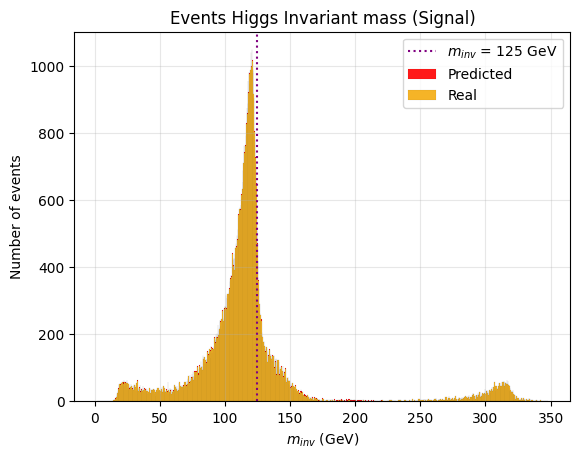

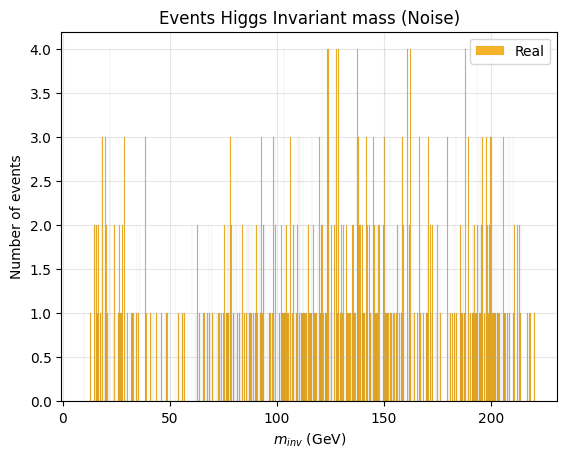

In [15]:
# Check the predictions
model = keras.models.load_model("/tf/Higgs-Boson-LHC-Collision-Detector/Trials-ANN/ResNet-SnB-Higgs_B-Classificator.keras")

y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

real_data = pd.concat([signal, noise])
predicted_data = real_data.drop(columns = ["label"])
predicted_data["label"] = y_pred_classes

df_predicted_signal = predicted_data[predicted_data["label"] != 1].copy()
df_real_signal = real_data[real_data["label"] != 1].copy()

df_predicted_background = predicted_data[predicted_data["label"] == 1].copy()
df_real_background = real_data[real_data["label"] == 1].copy()

sns.histplot(df_predicted_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.axvline(x = 125, color = "purple", linestyle = ':', label = rf"$m_{{inv}}$ = 125 GeV")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Higgs Invariant mass (Signal)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

sns.histplot(df_predicted_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Higgs Invariant mass (Noise)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()